# Projet 6 — Crédit / Default Risk (Partie 1)
## Notebook 01 — EDA + contrôle qualité + dataset final

Objectif :
- Charger le dataset `features.parquet` généré par le pipeline (reproductible).
- Vérifier la structure (train/test via TARGET).
- Quantifier l’imbalance de la cible.
- Analyser les valeurs manquantes et quelques distributions clés.
- Sauvegarder un petit dataset de référence pour le monitoring (Partie 2).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from credexp.config import DATA_DIR, settings
from credexp.data.io import load_parquet


In [2]:
features_path = DATA_DIR / "processed" / "features.parquet"
df = load_parquet(features_path)
df.shape, df.columns[:10]


{"ts": "2026-02-17T18:13:25Z", "level": "INFO", "name": "credexp.data.io", "msg": "load_parquet path=G:\\Mon Drive\\OC\\Projet_6\\credexp\\data\\processed\\features.parquet"}


((356251, 797),
 Index(['SK_ID_CURR', 'TARGET', 'CODE_GENDER', 'FLAG_OWN_CAR',
        'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
        'AMT_ANNUITY', 'AMT_GOODS_PRICE'],
       dtype='object'))

In [3]:
assert "TARGET" in df.columns, "TARGET column is missing!"
df_train = df[df["TARGET"].notna()].copy()
df_test  = df[df["TARGET"].isna()].copy()

df_train.shape, df_test.shape


((307507, 797), (48744, 797))

In [4]:
y = df_train["TARGET"].astype(int)
y.value_counts(), y.mean()


(TARGET
 0    282682
 1     24825
 Name: count, dtype: int64,
 0.08072986956394489)

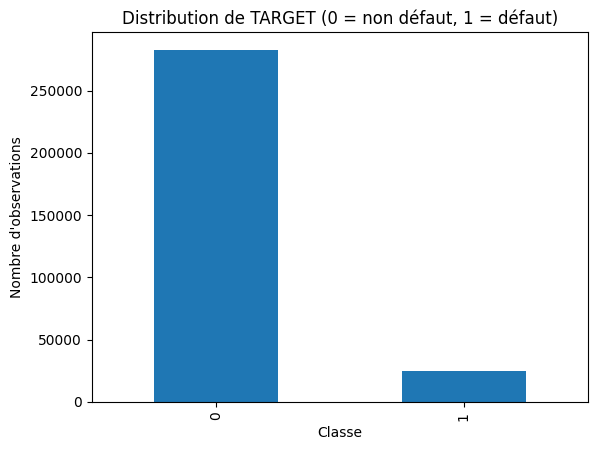

Taux de défaut (TARGET=1): 0.0807


In [5]:
plt.figure()
y.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de TARGET (0 = non défaut, 1 = défaut)")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.show()

print(f"Taux de défaut (TARGET=1): {y.mean():.4f}")


In [6]:
df_train.dtypes.value_counts()


float64    606
bool       133
int64       42
object      16
Name: count, dtype: int64

In [7]:
missing_rate = df_train.isna().mean().sort_values(ascending=False)
missing_rate.head(20)


REFUSED_AMT_DOWN_PAYMENT_MAX          0.853116
REFUSED_AMT_DOWN_PAYMENT_MEAN         0.853116
REFUSED_AMT_DOWN_PAYMENT_MIN          0.853116
REFUSED_RATE_DOWN_PAYMENT_MEAN        0.853116
REFUSED_RATE_DOWN_PAYMENT_MAX         0.853116
REFUSED_RATE_DOWN_PAYMENT_MIN         0.853116
REFUSED_APP_CREDIT_PERC_VAR           0.840143
CC_AMT_PAYMENT_CURRENT_VAR            0.802870
CC_CNT_DRAWINGS_POS_CURRENT_VAR       0.802629
CC_AMT_DRAWINGS_OTHER_CURRENT_VAR     0.802629
CC_CNT_DRAWINGS_OTHER_CURRENT_VAR     0.802629
CC_AMT_DRAWINGS_POS_CURRENT_VAR       0.802629
CC_CNT_DRAWINGS_ATM_CURRENT_VAR       0.802629
CC_AMT_DRAWINGS_ATM_CURRENT_VAR       0.802629
CC_AMT_PAYMENT_CURRENT_MEAN           0.801435
CC_AMT_PAYMENT_CURRENT_MAX            0.801435
CC_AMT_PAYMENT_CURRENT_MIN            0.801435
CC_AMT_DRAWINGS_OTHER_CURRENT_MEAN    0.801175
CC_AMT_DRAWINGS_OTHER_CURRENT_MAX     0.801175
CC_AMT_DRAWINGS_POS_CURRENT_MIN       0.801175
dtype: float64

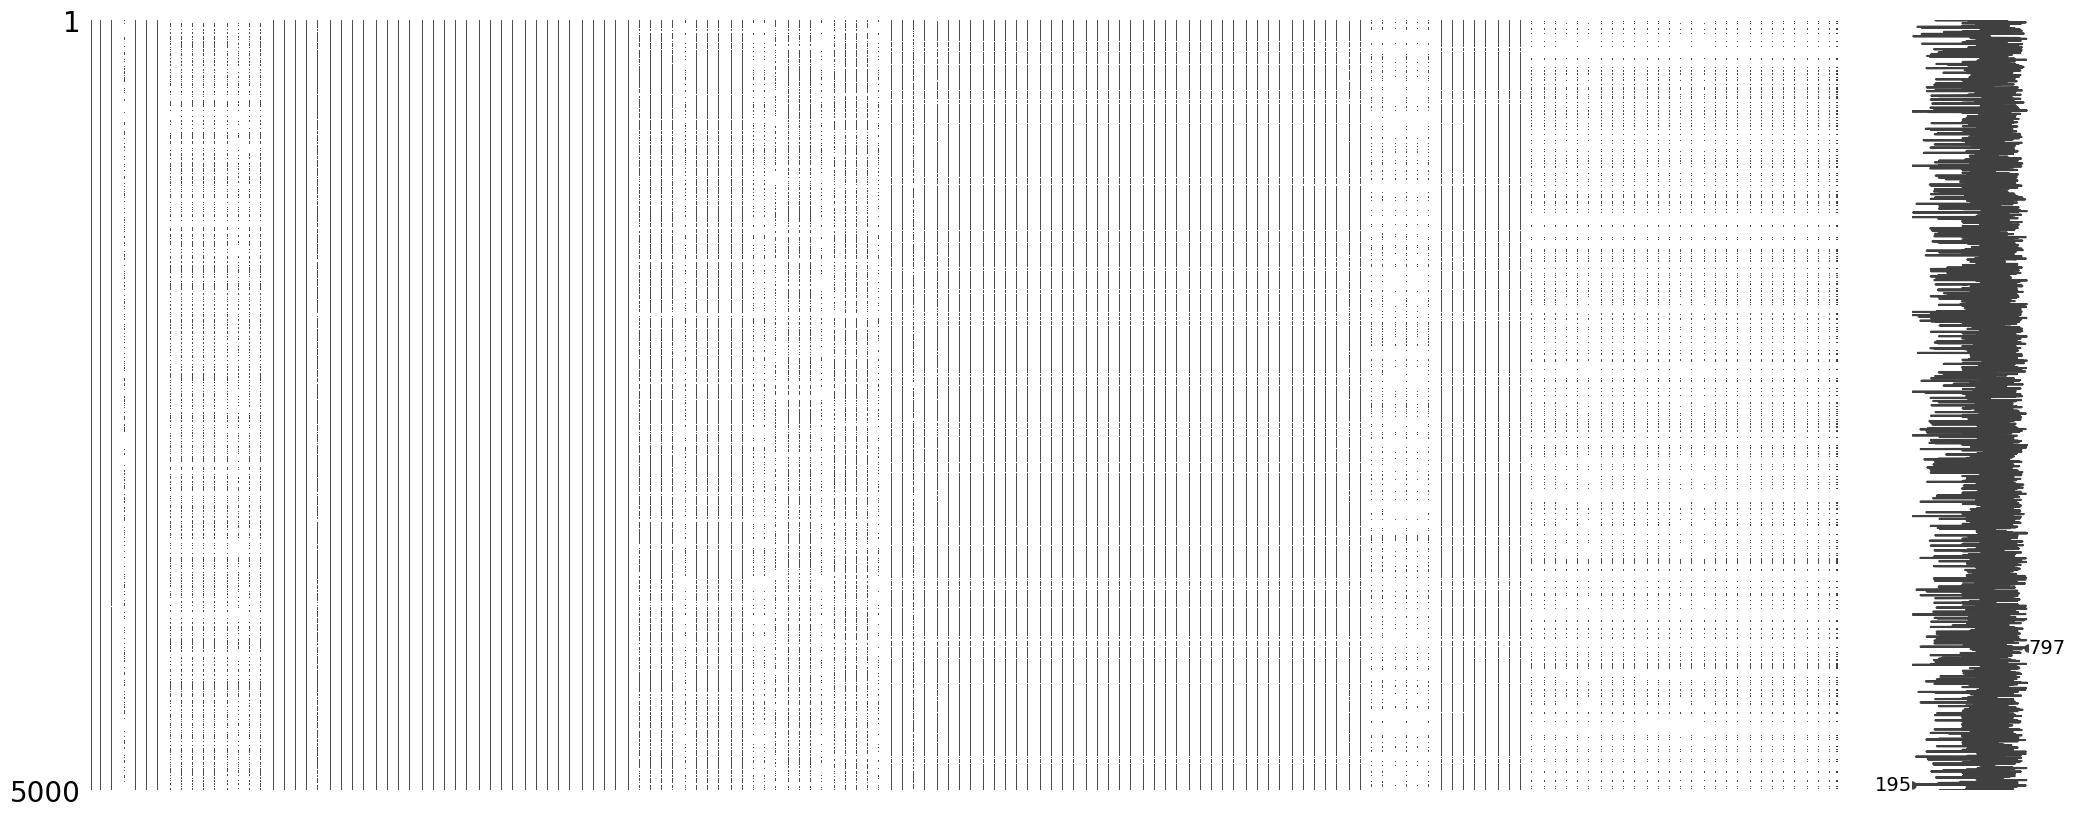

In [8]:
sample = df_train.sample(n=min(5000, len(df_train)), random_state=settings.random_state)
msno.matrix(sample)
plt.show()


In [9]:
high_missing = missing_rate[missing_rate > 0.8]
len(high_missing), high_missing.head()


(37,
 REFUSED_AMT_DOWN_PAYMENT_MAX      0.853116
 REFUSED_AMT_DOWN_PAYMENT_MEAN     0.853116
 REFUSED_AMT_DOWN_PAYMENT_MIN      0.853116
 REFUSED_RATE_DOWN_PAYMENT_MEAN    0.853116
 REFUSED_RATE_DOWN_PAYMENT_MAX     0.853116
 dtype: float64)

On observe des variables avec >80% de valeurs manquantes.
Décision : **ne pas supprimer ici** (pour rester fidèle au pipeline Kaggle et laisser le modèle gérer),
mais garder cette info pour :
- ablation study / feature selection plus tard,
- et/ou imputation adaptée.



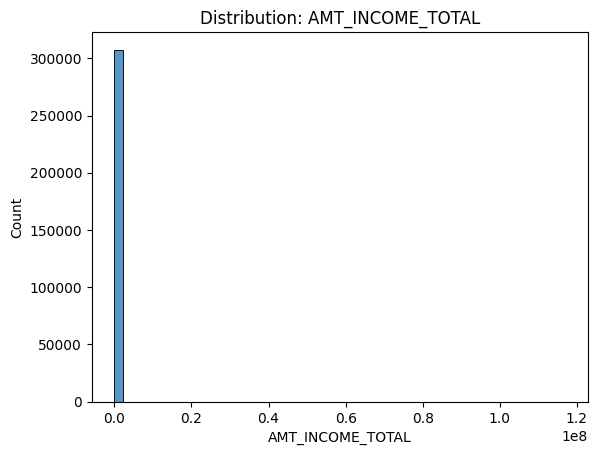

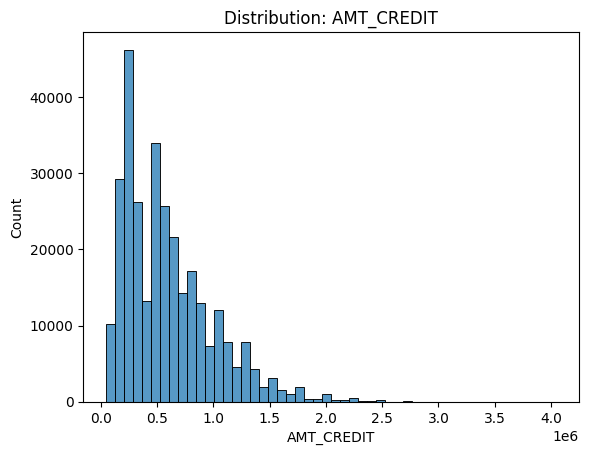

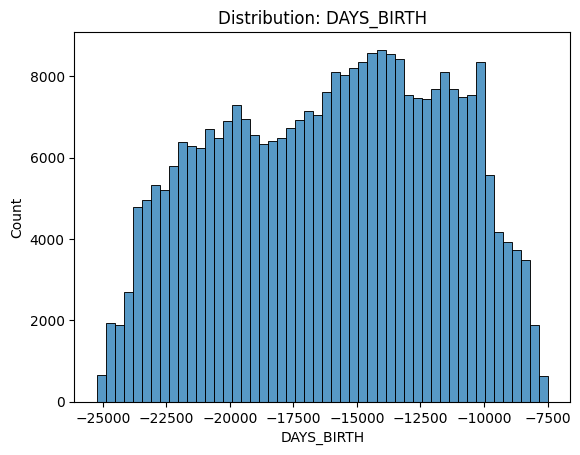

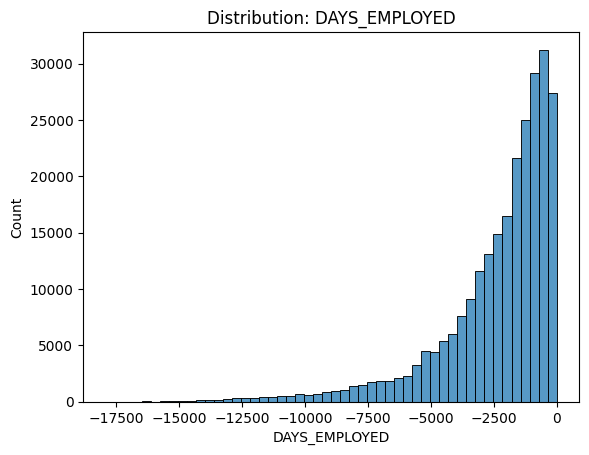

In [10]:
cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "DAYS_BIRTH", "DAYS_EMPLOYED"]
cols = [c for c in cols if c in df_train.columns]

for c in cols:
    plt.figure()
    sns.histplot(df_train[c].dropna(), bins=50)
    plt.title(f"Distribution: {c}")
    plt.show()


In [11]:
ref_path = DATA_DIR / "processed" / "reference.parquet"
ref = df_train.sample(n=min(20000, len(df_train)), random_state=settings.random_state)
ref.to_parquet(ref_path, index=False)
ref_path


WindowsPath('G:/Mon Drive/OC/Projet_6/credexp/data/processed/reference.parquet')